In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/brandao/diabetes/description.pdf
/kaggle/input/datasets/brandao/diabetes/diabetic_data.csv


In [43]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/brandao/diabetes/description.pdf
/kaggle/input/datasets/brandao/diabetes/diabetic_data.csv


# Hospital Readmission Prediction

### Case Study 1: Predicting 30-Day Hospital Readmission

**Model:** Logistic Regression with L2 Regularization  
**Dataset:** Diabetes 130-US Hospitals for Years 1999-2008

### Objective
To predict whether a diabetic patient will be readmitted to the hospital within 30 days of discharge using patient diagnosis, hospital stay, and previous visit information.

### Evaluation Metrics
- ROC-AUC
- Confusion Matrix
- Precision
- Recall

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [45]:
data_path = "/kaggle/input/datasets/brandao/diabetes/diabetic_data.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [46]:
print("Rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Rows and columns: (101766, 50)

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [48]:
print(df["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


## Creating the Target Variable

The original `readmitted` column contains three categories:

- `<30` = readmitted within 30 days
- `>30` = readmitted after 30 days
- `NO` = not readmitted

For this case study, the target is converted into a binary variable where `1` represents readmission within 30 days and `0` represents all other cases.

In [49]:
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30"].value_counts())

readmitted_30
0    90409
1    11357
Name: count, dtype: int64


## Feature Selection

The following features are used for prediction:

- Diagnosis codes: `diag_1`, `diag_2`, `diag_3`
- Hospital stay information: `time_in_hospital`
- Laboratory procedures: `num_lab_procedures`
- Previous healthcare utilization: `number_outpatient`, `number_emergency`, `number_inpatient`

In [50]:
features = [
    "diag_1",
    "diag_2",
    "diag_3",
    "time_in_hospital",
    "num_lab_procedures",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

target = "readmitted_30"

X = df[features]
y = df[target]

print("Selected features:")
print(features)

print("\nTarget distribution:")
print(y.value_counts())

Selected features:
['diag_1', 'diag_2', 'diag_3', 'time_in_hospital', 'num_lab_procedures', 'number_outpatient', 'number_emergency', 'number_inpatient']

Target distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64


## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split.

Stratified sampling is used so that the proportion of 30-day readmissions remains similar in both sets.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 81412
Testing samples: 20354


In [52]:
categorical_features = [
    "diag_1",
    "diag_2",
    "diag_3"
]

numerical_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

# Preprocessing

using One-Hot Encoding because diagnosis codes are categorical rather than naturally ordered numerical values.

In [53]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features),
        ("num", numerical_transformer, numerical_features)
    ]
)

## Logistic Regression with L2 Regularization

Logistic Regression is used as the classification model.

L2 regularization is applied to help control model complexity. Class weighting is also used because the number of patients readmitted within 30 days is much smaller than the number of patients not readmitted within 30 days.

In [55]:
model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [56]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [57]:
pipeline.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


# Now we'll finish the evaluation section and then do the clinical interpretation.

The UCI dataset explicitly frames the task as predicting early readmission within 30 days, and it provides no required train/test split, so our 80/20 stratified split is a reasonable assessment setup.

In [58]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)

print("Predictions generated successfully.")
print("\nFirst 10 predicted probabilities:")
print(y_prob[:10])

Predictions generated successfully.

First 10 predicted probabilities:
[0.5409016  0.33287541 0.4233902  0.69254629 0.37446091 0.22583653
 0.33111988 0.40351096 0.70355178 0.68406498]


y_prob = probability that the patient will be readmitted within 30 days.

y_pred = final 0/1 prediction using Logistic Regression's default threshold of 0.50.

In [59]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.6338


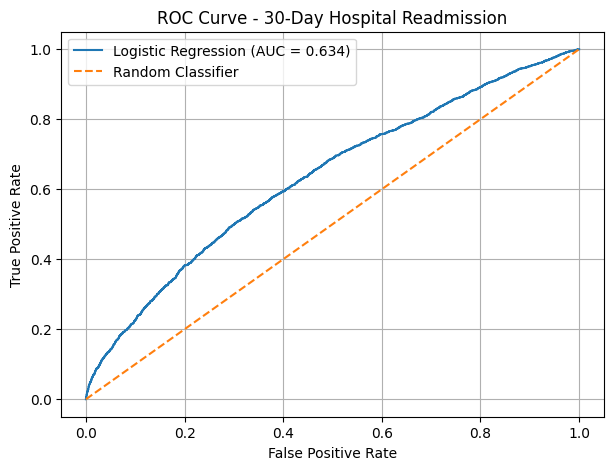

In [60]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Hospital Readmission")
plt.legend()
plt.grid()
plt.show()

# Confusion matrix

In [61]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11920  6163]
 [ 1042  1229]]


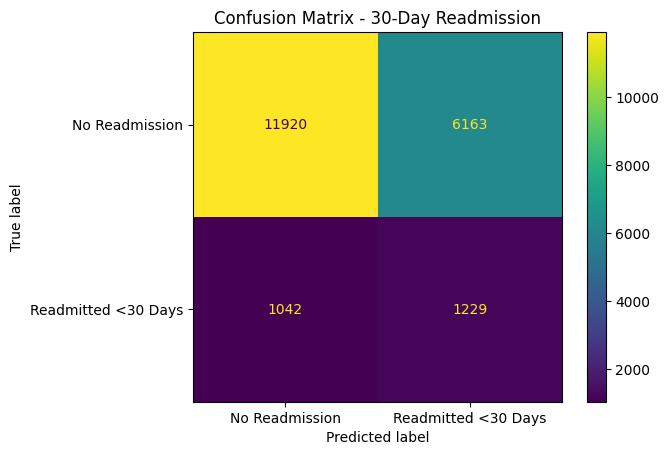

In [62]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Readmission",
        "Readmitted <30 Days"
    ]
)

disp.plot()
plt.title("Confusion Matrix - 30-Day Readmission")
plt.show()

In [63]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "No Readmission",
        "Readmitted <30 Days"
    ]
))

                     precision    recall  f1-score   support

     No Readmission       0.92      0.66      0.77     18083
Readmitted <30 Days       0.17      0.54      0.25      2271

           accuracy                           0.65     20354
          macro avg       0.54      0.60      0.51     20354
       weighted avg       0.84      0.65      0.71     20354



In [64]:
tn, fp, fn, tp = cm.ravel()

print("Model Results")
print("-" * 30)
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")

Model Results
------------------------------
ROC-AUC   : 0.6338
True Negatives  : 11920
False Positives : 6163
False Negatives : 1042
True Positives  : 1229


## Clinical Interpretation: False Positives vs False Negatives

A false negative occurs when the model predicts that a patient will not be readmitted within 30 days, but the patient is actually readmitted.

In this application, a false negative can be important because a patient who is actually at risk may not receive additional monitoring or follow-up based on the model's prediction.

A false positive occurs when the model predicts 30-day readmission, but the patient is not actually readmitted.

False positives can result in additional follow-up, testing, or use of healthcare resources.

Therefore, both types of errors should be considered when using the model in a clinical setting. The relative cost of false positives and false negatives would depend on how the prediction is used and what intervention is associated with a high-risk prediction.

# Threshold Analysis
one small experiment to show what happens if we lower the classification threshold.

In [65]:
threshold = 0.40

y_pred_40 = (y_prob >= threshold).astype(int)

cm_40 = confusion_matrix(y_test, y_pred_40)

print("Confusion Matrix at threshold =", threshold)
print(cm_40)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_40,
    target_names=[
        "No Readmission",
        "Readmitted <30 Days"
    ]
))

Confusion Matrix at threshold = 0.4
[[ 6487 11596]
 [  496  1775]]

Classification Report:
                     precision    recall  f1-score   support

     No Readmission       0.93      0.36      0.52     18083
Readmitted <30 Days       0.13      0.78      0.23      2271

           accuracy                           0.41     20354
          macro avg       0.53      0.57      0.37     20354
       weighted avg       0.84      0.41      0.49     20354



### Threshold Observation

The default classification threshold of 0.50 was compared with a lower threshold of 0.40.

At a threshold of 0.50, the model achieved a recall of approximately 54.12%, with 1,042 false negatives.

When the threshold was lowered to 0.40, recall increased to approximately 78.16%, while false negatives decreased to 496. However, false positives increased substantially from 6,163 to 11,596, and precision decreased from approximately 16.63% to 13.27%.

This demonstrates the trade-off involved in selecting a classification threshold. A lower threshold identifies more patients who are actually readmitted, but it also classifies more patients as high risk when they are not readmitted. In a clinical application, the appropriate threshold would depend on the consequences and resources associated with false positives and false negatives.

# Conclusion

Logistic Regression with L2 regularization was used to predict 30-day hospital readmission among diabetic patients.

The selected features included diagnosis codes, time spent in the hospital, laboratory procedures, and previous outpatient, emergency, and inpatient visits. Categorical diagnosis features were one-hot encoded, while numerical features were imputed and scaled before training.

The model was evaluated using ROC-AUC, a confusion matrix, precision, recall, and F1-score.

The model achieved a **ROC-AUC of 0.6338** on the test set. At the default classification threshold, the model produced **1,229 true positives, 11,920 true negatives, 6,163 false positives, and 1,042 false negatives**.

The recall was approximately **54.12%**, meaning that the model identified about 54% of the patients who were actually readmitted within 30 days. The model also produced a relatively large number of false positives, which indicates that many patients were classified as high risk even though they were not readmitted.

In a clinical setting, false negatives may be important because they represent patients who were actually readmitted within 30 days but were not identified as high risk. However, false positives can also result in additional follow-up or use of healthcare resources. Therefore, the appropriate classification threshold would depend on the consequences of each type of error and how the prediction is used.

Overall, the model demonstrates how Logistic Regression with L2 regularization can be used to identify patients at risk of early hospital readmission. The results also show that additional patient, clinical, and hospital-related features could be explored to improve predictive performance.